<a href="https://colab.research.google.com/github/dsdsgege/vision-robustness-analyzing/blob/tamas_dev/ProjectFile_AGLU8T.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
from IPython.testing import test
import numpy as np
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torch.utils.data import DataLoader, random_split
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [163]:
# Adathalmaz kiválasztása
dataset_name = 'mnist'  # Lehetőségek: 'mnist', 'cifar10', 'cifar100'

# Tanulási paraméterek
epochs = 13
learning_rate = 1e-3
batch_size = 100
weight_decay = 1e-5 #L2 regularizációs együttható

# Modell architektúra paraméterei
input_dim = 28*28
hidden_units = 512
num_layers = 4
num_classes = 10
activation_fn = nn.ReLU

#Regularizáció
use_batchnorm = True
dropout_rate = 0.2

# Optimalizáló és Veszteségfüggvény kiválasztása
optimizer_class = torch.optim.Adam
criterion_class = nn.CrossEntropyLoss

In [164]:
class DataManager:
    def __init__(self, dataset_name='mnist', data_dir='./data', batch_size=100, valid_split=0.2, test_split=0.1, num_workers=2):
        """
        Inicializálja az adatkezelő osztályt.
        """
        self.dataset_name = dataset_name.lower()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.valid_split = valid_split
        self.test_split = test_split
        self.num_workers = num_workers

        # Adathalmazok leképezése stringről a megfelelő torchvision osztályra
        self.datasets_dict = {
            "mnist": datasets.MNIST,
            'cifar10': datasets.CIFAR10,
            'cifar100': datasets.CIFAR100,
            'imagenet': datasets.ImageNet
        }

        if self.dataset_name not in self.datasets_dict:
            raise ValueError(f"Nem támogatott adathalmaz: {self.dataset_name}. Választható: {list(self.datasets_dict.keys())}")

        self.DatasetClass = self.datasets_dict[self.dataset_name]

    def _get_mean_std(self):
        """Kiszámolja vagy betölti az adathalmaz átlagát és szórását a normalizáláshoz."""
        if self.dataset_name == 'imagenet':
            return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

        print(f"{self.dataset_name} statisztikák (átlag, szórás) számítása...")
        temp_transform = transforms.Compose([transforms.ToTensor()])
        temp_set = self.DatasetClass(root=self.data_dir, train=True, download=True, transform=temp_transform)

        data = temp_set.data
        if not torch.is_tensor(data):
            data = torch.from_numpy(data)

        data = data.float() / 255.0

        if data.ndim == 3: # MNIST (B, H, W)
            mean = data.mean().item()
            std = data.std().item()
            return [mean], [std]
        else: # CIFAR stb (B, H, W, C) vagy (B, C, H, W)
            mean = data.mean(axis=(0, 1, 2)).tolist()
            std = data.std(axis=(0, 1, 2)).tolist()
            return mean, std

    def get_loaders(self):
        """Létrehozza és visszaadja a DataLoader objektumokat."""
        mean, std = self._get_mean_std()

        transform_pipeline = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])

        if self.dataset_name == 'imagenet':
            full_train_dataset = self.DatasetClass(root=self.data_dir, split='train', transform=transform_pipeline)
        else:
            full_train_dataset = self.DatasetClass(root=self.data_dir, train=True, download=True, transform=transform_pipeline)

        total_train_size = len(full_train_dataset)
        valid_size = int(total_train_size * self.valid_split)
        test_size = int(total_train_size * self.test_split)
        train_size = total_train_size - valid_size - test_size

        train_dataset, valid_dataset, test_dataset = random_split(full_train_dataset, [train_size, valid_size, test_size])

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
        valid_loader = DataLoader(valid_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

        return train_loader, valid_loader, test_loader

In [165]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [166]:
# Early Stopping és Model Saving paraméterek
use_early_stopping = True
patience = 3
min_delta = 0.001
save_best_model = True
best_model_path = 'best_model.pth'

In [171]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.block(x)
        out += identity
        return self.relu(out)

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, act_fn, use_bn=True, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()

        # Bemeneti réteg
        layers = [nn.Linear(input_dim, hidden_dim)]
        if use_bn: layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(act_fn())
        if dropout > 0: layers.append(nn.Dropout(dropout))

        # Maradék blokkok hozzáadása
        for _ in range(num_layers - 1):
            layers.append(ResidualBlock(hidden_dim, dropout))

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden_layers(x)
        return self.output_layer(x)

A hálózat mostantól Residual alapú architektúrát használ!


In [167]:
class EarlyStopper:
    def __init__(self, patience=2, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

def validate_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    val_loss = 0
    correct = 0
    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss /= num_batches
    accuracy = correct / len(dataloader.dataset)
    return val_loss, accuracy

In [172]:
model = NeuralNetwork(
    input_dim=input_dim,
    hidden_dim=hidden_units,
    num_layers=num_layers,
    num_classes=num_classes,
    act_fn=activation_fn,
    use_bn=use_batchnorm,
    dropout=dropout_rate
).to(device)

loss_fn = criterion_class()
optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

eary_stopper = EarlyStopper(patience=patience, min_delta=min_delta)
best_model_path = f'best_model_{dataset_name}.pth'
best_vloss = float('inf')

# Listák az eredmények tárolásához
train_losses = []
valid_losses = []
valid_accuracies = []
test_losses = []
test_accuracies = []

# Adatbetöltők
dm = DataManager(dataset_name=dataset_name, batch_size=batch_size, valid_split=0.2, test_split=0.1)
train_loader, valid_loader, test_loader = dm.get_loaders()

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    # Tanítás és a tanítási veszteség rögzítése
    train_loop(train_loader, model, loss_fn, optimizer)

    # Kiszámoljuk a tanítási veszteséget az epoch végén a grafikonhoz
    train_loss, _ = validate_loop(train_loader, model, loss_fn)
    train_losses.append(train_loss)

    v_loss, v_acc = validate_loop(valid_loader, model, loss_fn)
    valid_losses.append(v_loss)
    valid_accuracies.append(v_acc)

    t_loss, t_acc = validate_loop(test_loader, model, loss_fn)
    test_losses.append(t_loss)
    test_accuracies.append(t_acc)

    print(f"Train Loss: {train_loss:>8f}")
    print(f"Validation - Loss: {v_loss:>8f}, Acc: {(100*v_acc):>0.1f}%")

    if v_loss < best_vloss:
        best_vloss = v_loss
        torch.save(model.state_dict(), best_model_path)

    if use_early_stopping and eary_stopper.early_stop(v_loss):
        print(f"Early stopping aktiválva!")
        break

print("Tanítás befejezve.")

mnist statisztikák (átlag, szórás) számítása...


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Epoch 1
-------------------------------
loss: 2.772862  [    0/42000]
loss: 0.234649  [10000/42000]
loss: 0.104957  [20000/42000]
loss: 0.129171  [30000/42000]
loss: 0.113708  [40000/42000]
Train Loss: 0.098105
Validation - Loss: 0.130930, Acc: 96.0%
Test       - Loss: 0.134402, Acc: 95.8%
Epoch 2
-------------------------------
loss: 0.137620  [    0/42000]
loss: 0.058085  [10000/42000]
loss: 0.098954  [20000/42000]
loss: 0.140068  [30000/42000]
loss: 0.047088  [40000/42000]
Train Loss: 0.061417
Validation - Loss: 0.104140, Acc: 96.9%
Test       - Loss: 0.098784, Acc: 97.1%
Epoch 3
-------------------------------
loss: 0.097747  [    0/42000]
loss: 0.047508  [10000/42000]
loss: 0.124929  [20000/42000]
loss: 0.013890  [30000/42000]
loss: 0.031627  [40000/42000]
Train Loss: 0.042133
Validation - Loss: 0.084715, Acc: 97.5%
Test       - Loss: 0.082144, Acc: 97.6%
Epoch 4
-------------------------------
loss: 0.108376  [    0/42000]
loss: 0.030990  [10000/42000]
loss: 0.091548  [20000/4200

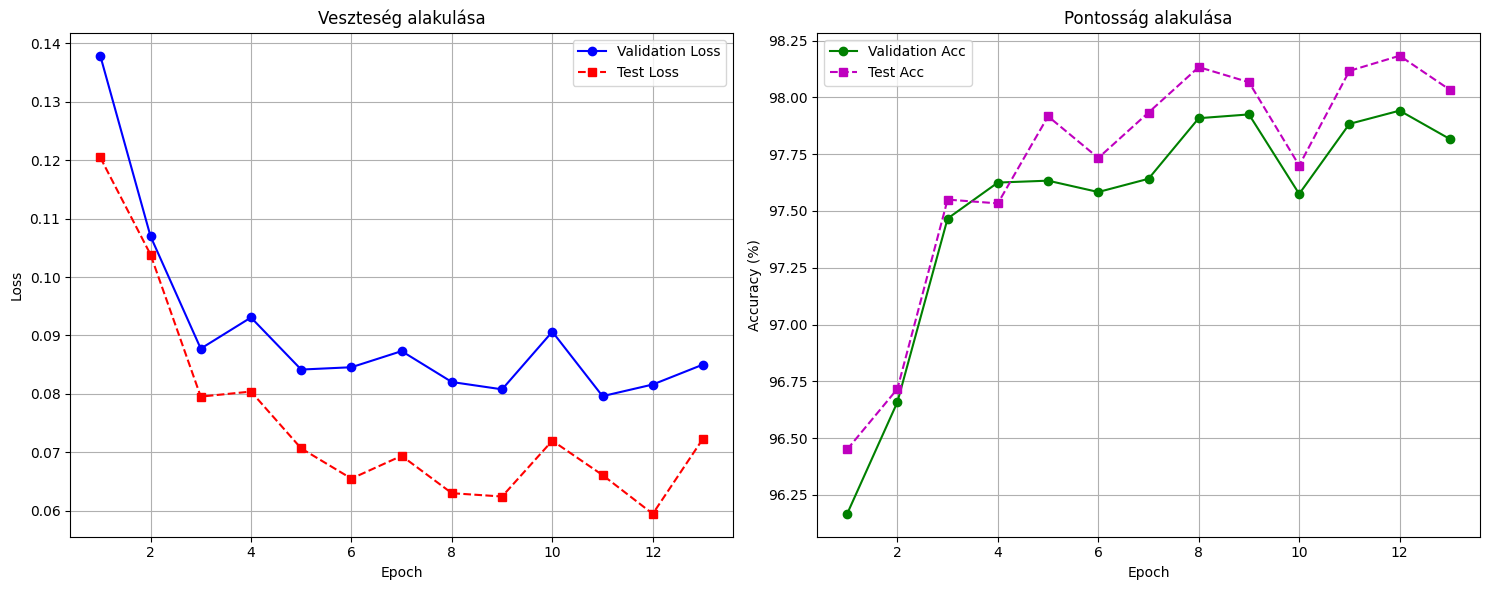

In [169]:
import matplotlib.pyplot as plt

if not valid_accuracies:
    print("Nincsenek adatok a megjelenítéshez.")
else:
    epochs_range = range(1, len(valid_accuracies) + 1)
    plt.figure(figsize=(15, 6))

    # Veszteség (Loss) összehasonlítás
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, valid_losses, 'b-o', label='Validation Loss')
    plt.plot(epochs_range, test_losses, 'r--s', label='Test Loss')
    plt.title('Veszteség alakulása')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Pontosság (Accuracy) összehasonlítás
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, [acc * 100 for acc in valid_accuracies], 'g-o', label='Validation Acc')
    plt.plot(epochs_range, [acc * 100 for acc in test_accuracies], 'm--s', label='Test Acc')
    plt.title('Pontosság alakulása')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

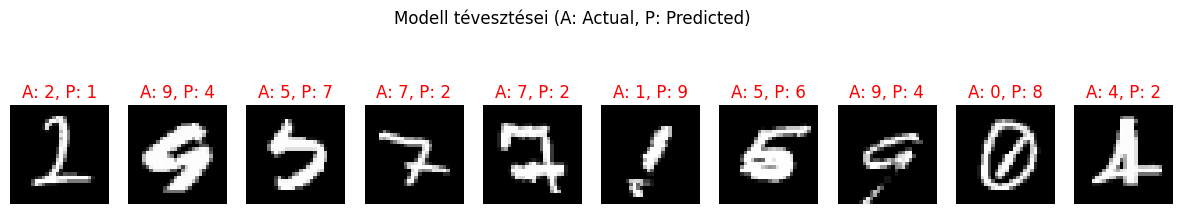

In [170]:
def visualize_misclassifications(dataloader, model, num_images=10):
    model.eval()
    misclassified_images = []
    actual_labels = []
    predicted_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            output = model(X)
            preds = output.argmax(1)

            # Megkeressük azokat az indexeket, ahol a predikció nem egyezik a címkével
            mistakes = (preds != y).nonzero(as_tuple=True)[0]

            for idx in mistakes:
                misclassified_images.append(X[idx].cpu())
                actual_labels.append(y[idx].item())
                predicted_labels.append(preds[idx].item())

                if len(misclassified_images) >= num_images:
                    break
            if len(misclassified_images) >= num_images:
                break

    # Megjelenítés
    plt.figure(figsize=(15, 3))
    for i in range(len(misclassified_images)):
        plt.subplot(1, num_images, i + 1)
        # Az MNIST adatok normalizáltak, visszalakítjuk a megjelenítéshez
        img = misclassified_images[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f"A: {actual_labels[i]}, P: {predicted_labels[i]}", color='red')
        plt.axis('off')
    plt.suptitle("Modell tévesztései (A: Actual, P: Predicted)")
    plt.show()

# Tévesztések megjelenítése a teszt adatokon
visualize_misclassifications(test_loader, model)